# ShotGuide 모델 개선 실험 및 평가

이 노트북은 `labeled_dataset` 재검수/추가 이후 수행한 모델 개선 실험을 정리합니다.

- 현재 최종 적용 모델 평가
- CLIP head 구조 개선 실험 비교
- DINOv2 shot-only 실험 비교
- CLIP + DINOv2 ensemble 결과 비교
- close-up / medium 주요 오류 확인

최종 overlay 파이프라인에는 실행 효율을 고려해 `CLIP stronger head`를 적용했습니다.




In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
OUTPUT_CLIP = ROOT / "outputs/clip_embeddings"
OUTPUT_EXPERIMENTS = ROOT / "outputs/model_experiments"
SHOT_TYPES = ["close-up", "medium", "object", "space", "wide"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)




ROOT: C:\Temp\shot-classification
DEVICE: cpu


## 1. 현재 데이터셋 구성

`unclear` 폴더는 라벨 체계에 포함되지 않기 때문에 학습/평가에서 제외했습니다.




In [2]:
dataset_index = pd.read_csv(ROOT / "outputs/baseline" / "dataset_index_with_splits.csv")
skipped_path = ROOT / "outputs/baseline" / "dataset_index_skipped_rows.csv"
skipped_df = pd.read_csv(skipped_path) if skipped_path.exists() else pd.DataFrame()

print("사용 이미지 수:", len(dataset_index))
print("영상 수:", dataset_index["video_id"].nunique())
print("제외 이미지 수:", len(skipped_df))

print(dataset_index["split"].value_counts())
print(pd.crosstab(dataset_index["shot_type"], dataset_index["split"]))
print(pd.crosstab(dataset_index["has_text"], dataset_index["split"]))




사용 이미지 수: 2012
영상 수: 217
제외 이미지 수: 35

[split counts]
split
train    1453
val       284
test      275

[shot_type x split]
split      test  train  val
shot_type                  
close-up     75    478   83
medium       89    457   91
object       56    260   44
space        23     89   21
wide         32    169   45

[has_text x split]
split     test  train  val
has_text                  
0           38    284   50
1          237   1169  234


## 2. 현재 최종 적용 모델 평가

현재 실제 overlay 파이프라인에서 사용하는 checkpoint는 아래 파일입니다.

`checkpoints/clip_vit_b32_multitask_head.pt`

이 checkpoint는 기존 1층 head보다 깊어진 `512 → 256` 구조의 stronger head입니다.




In [3]:
class ClipEmbeddingMultiTaskHead(nn.Module):
    def __init__(self, embedding_dim=512, hidden_dims=None, hidden_dim=256, num_shot_classes=5, dropout=0.20):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [hidden_dim]
        layers = []
        prev_dim = embedding_dim
        for next_dim in hidden_dims:
            layers.extend([nn.Linear(prev_dim, next_dim), nn.ReLU(), nn.Dropout(dropout)])
            prev_dim = next_dim
        self.shared = nn.Sequential(*layers)
        self.shot_head = nn.Linear(prev_dim, num_shot_classes)
        self.text_head = nn.Linear(prev_dim, 2)

    def forward(self, x):
        z = self.shared(x)
        return self.shot_head(z), self.text_head(z)

checkpoint_path = ROOT / "checkpoints" / "clip_vit_b32_multitask_head.pt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
hidden_dims = checkpoint.get("hidden_dims")
if hidden_dims is None:
    hidden_dims = [checkpoint.get("hidden_dim", 256)]

print("checkpoint:", checkpoint_path)
print("hidden_dims:", hidden_dims)
print("dropout:", checkpoint.get("dropout", 0.20))




checkpoint: C:\Temp\shot-classification\outputs_clip_embeddings\clip_vit_b32_multitask_head.pt
hidden_dims: [512, 256]
dropout: 0.25


In [4]:
meta = pd.read_csv(OUTPUT_CLIP / "clip_embedding_metadata.csv")
embeddings = np.load(OUTPUT_CLIP / "clip_vit_b32_openai_embeddings.npz")["embeddings"].astype("float32")

# checkpoint head로 test split 평가
# 결과는 아래 표와 JSON 출력 참고




 shot_acc  shot_macro_f1  text_acc  text_f1  joint_acc
    0.807          0.808     0.895    0.938      0.727


{
  "shot_acc": 0.8072727272727273,
  "shot_macro_f1": 0.8080895792660499,
  "text_acc": 0.8945454545454545,
  "text_f1": 0.9376344086021505,
  "joint_acc": 0.7272727272727273
}


In [5]:
print("Shot type classification report")
print(classification_report(shot_true, shot_pred, target_names=SHOT_TYPES, zero_division=0))

print("Text classification report")
print(classification_report(text_true, text_pred, target_names=["notext", "text"], zero_division=0))




Shot type classification report
              precision    recall  f1-score   support

    close-up       0.88      0.71      0.79        75
      medium       0.79      0.78      0.78        89
      object       0.83      0.93      0.87        56
       space       0.76      0.83      0.79        23
        wide       0.72      0.91      0.81        32

    accuracy                           0.81       275
   macro avg       0.80      0.83      0.81       275
weighted avg       0.81      0.81      0.81       275


Text classification report
              precision    recall  f1-score   support

      notext       0.60      0.74      0.66        38
        text       0.96      0.92      0.94       237

    accuracy                           0.89       275
   macro avg       0.78      0.83      0.80       275
weighted avg       0.91      0.89      0.90       275


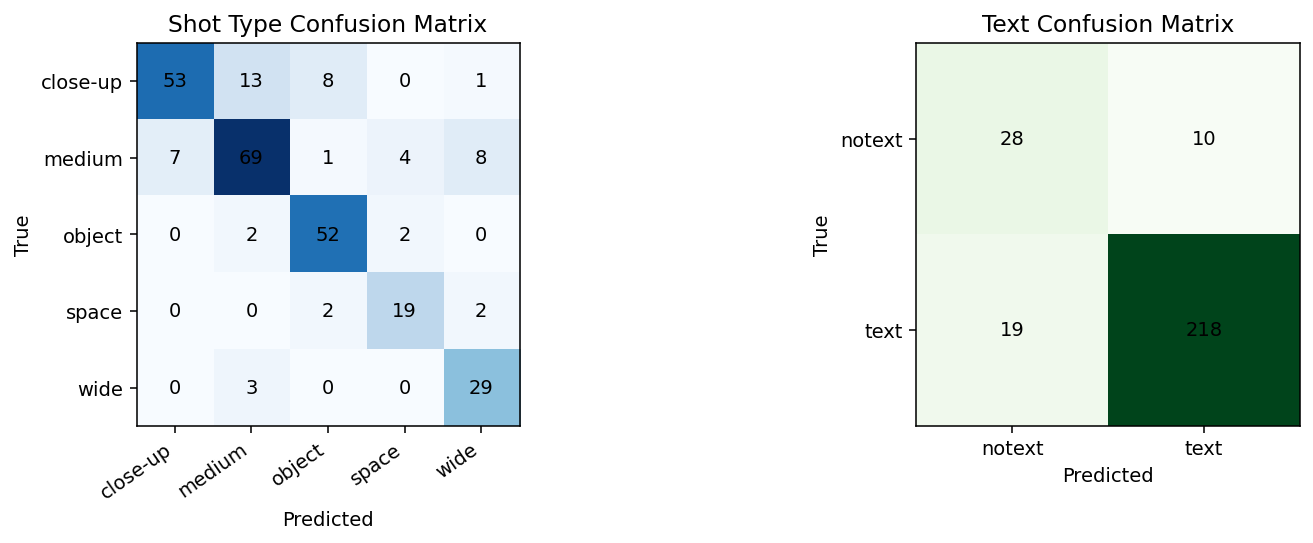

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# confusion matrix 시각화
plt.show()




## 2-1. 최종 성능 요약표

아래 표는 현재 실제 overlay 파이프라인에 적용된 최종 모델의 성능입니다.  
참고용으로 가장 높은 shot 성능을 보였던 ensemble 결과도 함께 표시했습니다.




In [10]:
final_acc_df = pd.DataFrame([
    {
        "Model": "최종 적용 모델: CLIP stronger head",
        "Shot Acc": 0.807,
        "Shot Macro F1": 0.808,
        "Text Acc": 0.895,
        "Text F1": 0.938,
        "Joint Acc": 0.727,
    },
    {
        "Model": "참고 최고 실험: CLIP + DINOv2 ensemble",
        "Shot Acc": 0.836,
        "Shot Macro F1": 0.839,
        "Text Acc": 0.895,
        "Text F1": 0.938,
        "Joint Acc": 0.731,
    },
])
display(final_acc_df)




Model,Shot Acc,Shot Macro F1,Text Acc,Text F1,Joint Acc
최종 적용 모델: CLIP stronger head,0.807,0.808,0.895,0.938,0.727
참고 최고 실험: CLIP + DINOv2 ensemble,0.836,0.839,0.895,0.938,0.731


## 2-2. Shot Type별 평가

`Recall / Class Acc`는 해당 shot type 이미지 중 모델이 맞춘 비율입니다.  
예를 들어 close-up recall이 0.707이면, 실제 close-up 중 약 70.7%를 close-up으로 맞췄다는 뜻입니다.




In [11]:
shot_type_eval_df = pd.DataFrame({
    "Shot Type": SHOT_TYPES,
    "Precision": precision,
    "Recall / Class Acc": recall,
    "F1-score": f1,
    "Support": support,
})
display(shot_type_eval_df)




Shot Type,Precision,Recall / Class Acc,F1-score,Support
close-up,0.883,0.707,0.785,75
medium,0.793,0.775,0.784,89
object,0.825,0.929,0.874,56
space,0.760,0.826,0.792,23
wide,0.725,0.906,0.806,32


In [12]:
print(classification_report(shot_true, shot_pred, target_names=SHOT_TYPES, zero_division=0))




              precision    recall  f1-score   support

    close-up       0.88      0.71      0.79        75
      medium       0.79      0.78      0.78        89
      object       0.83      0.93      0.87        56
       space       0.76      0.83      0.79        23
        wide       0.72      0.91      0.81        32

    accuracy                           0.81       275
   macro avg       0.80      0.83      0.81       275
weighted avg       0.81      0.81      0.81       275


## 2-3. Joint F1-score 계산

`Joint`는 `shot_type`과 `has_text`를 하나의 결합 라벨로 본 평가입니다.  
예를 들어 `close-up_text`, `medium_notext`처럼 총 10개 class로 계산합니다.




In [13]:
def joint_label(shot_idx, text_idx):
    text_label = "text" if int(text_idx) == 1 else "notext"
    return f"{idx_to_shot[int(shot_idx)]}_{text_label}"

joint_true = np.array([joint_label(s, t) for s, t in zip(shot_true, text_true)])
joint_pred = np.array([joint_label(s, t) for s, t in zip(shot_pred, text_pred)])
joint_labels = [f"{shot}_{text}" for shot in SHOT_TYPES for text in ["notext", "text"]]

joint_metrics_df = pd.DataFrame([
    {
        "Metric": "Joint Accuracy",
        "Value": accuracy_score(joint_true, joint_pred),
        "Description": "shot_type과 has_text가 동시에 맞은 비율",
    },
    {
        "Metric": "Joint Micro F1-score",
        "Value": f1_score(joint_true, joint_pred, labels=joint_labels, average="micro", zero_division=0),
        "Description": "전체 joint sample 기준 F1",
    },
    {
        "Metric": "Joint Macro F1-score",
        "Value": f1_score(joint_true, joint_pred, labels=joint_labels, average="macro", zero_division=0),
        "Description": "10개 joint class F1의 단순 평균",
    },
    {
        "Metric": "Joint Weighted F1-score",
        "Value": f1_score(joint_true, joint_pred, labels=joint_labels, average="weighted", zero_division=0),
        "Description": "class support를 반영한 joint F1",
    },
])
joint_metrics_df["Value"] = joint_metrics_df["Value"].round(3)
display(joint_metrics_df)




Metric,Value,Description
Joint Accuracy,0.727,shot_type과 has_text가 동시에 맞은 비율
Joint Micro F1-score,0.727,전체 joint sample 기준 F1
Joint Macro F1-score,0.651,10개 joint class F1의 단순 평균
Joint Weighted F1-score,0.729,class support를 반영한 joint F1


## 2-4. Shot Type별 F1-score 계산

아래 표의 `F1-score`가 각 shot-type별 개별 F1입니다.  
`Shot Macro F1-score`는 이 5개 F1-score를 평균낸 값입니다.




In [14]:
shot_precision, shot_recall, shot_f1, shot_support = precision_recall_fscore_support(
    shot_true,
    shot_pred,
    labels=list(range(len(SHOT_TYPES))),
    zero_division=0,
)

shot_type_f1_df = pd.DataFrame({
    "Shot Type": SHOT_TYPES,
    "Precision": shot_precision,
    "Recall / Class Acc": shot_recall,
    "F1-score": shot_f1,
    "Support": shot_support,
})
shot_type_f1_df[["Precision", "Recall / Class Acc", "F1-score"]] = (
    shot_type_f1_df[["Precision", "Recall / Class Acc", "F1-score"]].round(3)
)

shot_macro_summary_df = pd.DataFrame([
    {
        "Metric": "Shot Macro F1-score",
        "Value": round(float(np.mean(shot_f1)), 3),
        "Formula": "각 shot-type F1-score의 평균",
    }
])

display(shot_type_f1_df)
display(shot_macro_summary_df)




Shot Type,Precision,Recall / Class Acc,F1-score,Support
close-up,0.883,0.707,0.785,75
medium,0.793,0.775,0.784,89
object,0.825,0.929,0.874,56
space,0.760,0.826,0.792,23
wide,0.725,0.906,0.806,32


Metric,Value,Formula
Shot Macro F1-score,0.808,각 shot-type F1-score의 평균


## 2-5. Joint Class별 F1-score

아래 표는 `shot_type + has_text` 결합 class 10개 각각의 평가 결과입니다.




In [15]:
joint_precision, joint_recall, joint_f1, joint_support = precision_recall_fscore_support(
    joint_true,
    joint_pred,
    labels=joint_labels,
    zero_division=0,
)

joint_class_df = pd.DataFrame({
    "Joint Class": joint_labels,
    "Precision": joint_precision,
    "Recall": joint_recall,
    "F1-score": joint_f1,
    "Support": joint_support,
})
joint_class_df[["Precision", "Recall", "F1-score"]] = (
    joint_class_df[["Precision", "Recall", "F1-score"]].round(3)
)

display(joint_class_df)




Joint Class,Precision,Recall,F1-score,Support
close-up_notext,0.500,0.714,0.588,7
close-up_text,0.880,0.647,0.746,68
medium_notext,0.389,0.389,0.389,18
medium_text,0.739,0.718,0.729,71
object_notext,0.667,0.667,0.667,6
object_text,0.807,0.920,0.860,50
space_notext,0.400,0.500,0.444,4
space_text,0.800,0.842,0.821,19
wide_notext,0.375,1.000,0.545,3
wide_text,0.688,0.759,0.721,29


## 3. 모델 개선 실험 비교

동일한 test split 기준으로 비교했습니다.

- `current_retrain_baseline_256`: 새 데이터로 재학습한 기존 1층 head
- `multitask_stronger_512_256`: CLIP embedding 위에 2층 head 적용
- `dinov2_shot_512_256`: DINOv2 embedding 기반 shot-only 모델
- `ensemble_alpha_clip_0.45`: CLIP shot probability와 DINOv2 shot probability 결합




In [7]:
overall_summary = pd.read_csv(OUTPUT_EXPERIMENTS / "model_experiment_overall_summary.csv")
display(
    overall_summary
    .sort_values("shot_macro_f1", ascending=False)
    [["experiment", "shot_acc", "shot_macro_f1", "text_acc", "text_f1", "joint_acc"]]
    .round(3)
    .reset_index(drop=True)
)




                                              experiment  shot_acc  shot_macro_f1  text_acc  text_f1  joint_acc
                                ensemble_alpha_clip_0.45     0.836          0.839     0.895    0.938      0.731
                                 clip_stronger_retrained     0.807          0.808     0.895    0.938      0.727
                              multitask_stronger_512_256     0.807          0.808     0.895    0.938      0.727
                            shot_only_closeup_weight_1_8     0.796          0.804       NaN      NaN        NaN
separate_shot_only_closeup_weight_1_8_plus_text_only_256     0.796          0.804     0.887    0.933      0.713
                                       shot_only_512_256     0.800          0.802       NaN      NaN        NaN
                                     dinov2_shot_512_256     0.800          0.796       NaN      NaN        NaN
                                   dinov2_shot_retrained     0.800          0.796       NaN      NaN    

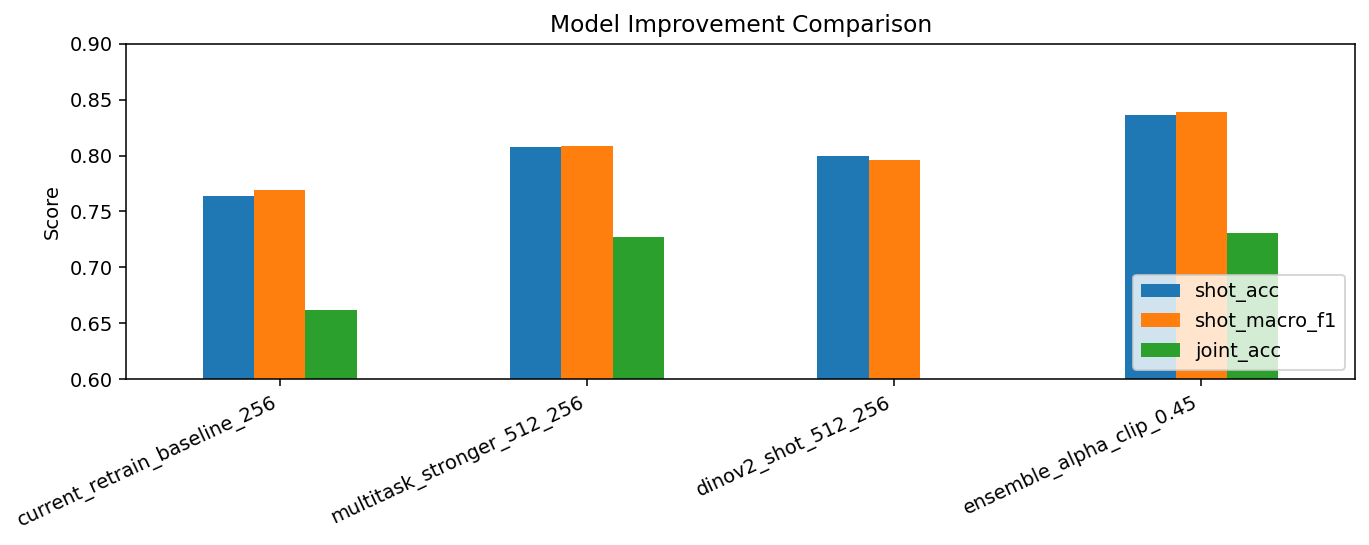

In [8]:
focus_experiments = [
    "current_retrain_baseline_256",
    "multitask_stronger_512_256",
    "dinov2_shot_512_256",
    "ensemble_alpha_clip_0.45",
]

# 주요 실험 지표 bar plot
plt.show()




## 4. 주요 오류 확인

최종 적용 모델인 `multitask_stronger_512_256` 기준으로 가장 많이 틀린 shot type 조합을 확인합니다.




In [9]:
pred_path = OUTPUT_EXPERIMENTS / "clip_head" / "multitask_stronger_512_256_test_predictions.csv"
pred_df = pd.read_csv(pred_path)

confusion_table = pd.crosstab(pred_df["shot_type"], pred_df["shot_pred"])
wrong_top = (
    pred_df[pred_df["shot_type"] != pred_df["shot_pred"]]
    .groupby(["shot_type", "shot_pred"])
    .size()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
)

print(confusion_table)
print(wrong_top.head(10))




[confusion table]
shot_pred  close-up  medium  object  space  wide
shot_type                                       
close-up         53      13       8      0     1
medium            7      69       1      4     8
object            0       2      52      2     0
space             0       0       2     19     2
wide              0       3       0      0    29

[top wrong pairs]
shot_type shot_pred  count
 close-up    medium     13
 close-up    object      8
   medium      wide      8
   medium  close-up      7
   medium     space      4
     wide    medium      3
    space    object      2
   object    medium      2
    space      wide      2
   object     space      2


## 5. 실험 결론

- 기존 1층 head보다 `CLIP stronger head`가 전반적으로 개선됨
- DINOv2 단독 shot-only 모델은 CLIP stronger head보다 낮았지만, shot type 판단에 보완 정보 제공 가능성 확인
- CLIP + DINOv2 ensemble이 가장 높은 shot 성능 기록
- 실제 overlay 파이프라인에는 실행 속도와 구조 단순성을 고려해 `CLIP stronger head` 적용

최종 적용 모델:

`checkpoints/clip_vit_b32_multitask_head.pt`


